# Project_1: To predict happiness

#### We need to predict the happiness score considering all the other factors mentioned in the dataset.

In [2]:
#Import Necessary Libraries
import numpy as np
import pandas as pd

#For DataVisualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

### 1. Load Dataset

In [6]:
data=pd.read_csv(r"C:\Users\HP\Downloads\Final Projects Machine Learning\Final Projects Machine Learning\Project 5.0\happiness_score_dataset.csv")
data.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [8]:
# Checking shape of our data (number of rows and columns)
data.shape

(158, 12)

In [10]:
# Checking the null values
data.isna().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [12]:
# There is no null values in our dataset

In [14]:
#Check any duplicate rows.
duplicate_rows = data[data.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [Country, Region, Happiness Rank, Happiness Score, Standard Error, Economy (GDP per Capita), Family, Health (Life Expectancy), Freedom, Trust (Government Corruption), Generosity, Dystopia Residual]
Index: []


In [16]:
# There is no duplicate rows we can go forward

In [18]:
# We are predicting Happiness score, so we can drop 'Happiness Rank'
data=data.drop(columns=['Happiness Rank'],axis=1)

In [20]:
# Describe our dataset
data.describe()

,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [22]:
df=data.drop(columns=['Country','Region'],axis=1)

In [24]:
df.head()

,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


### 2. EDA (Exploratory Data Analysis)

#### We can use distribution plots to understand data

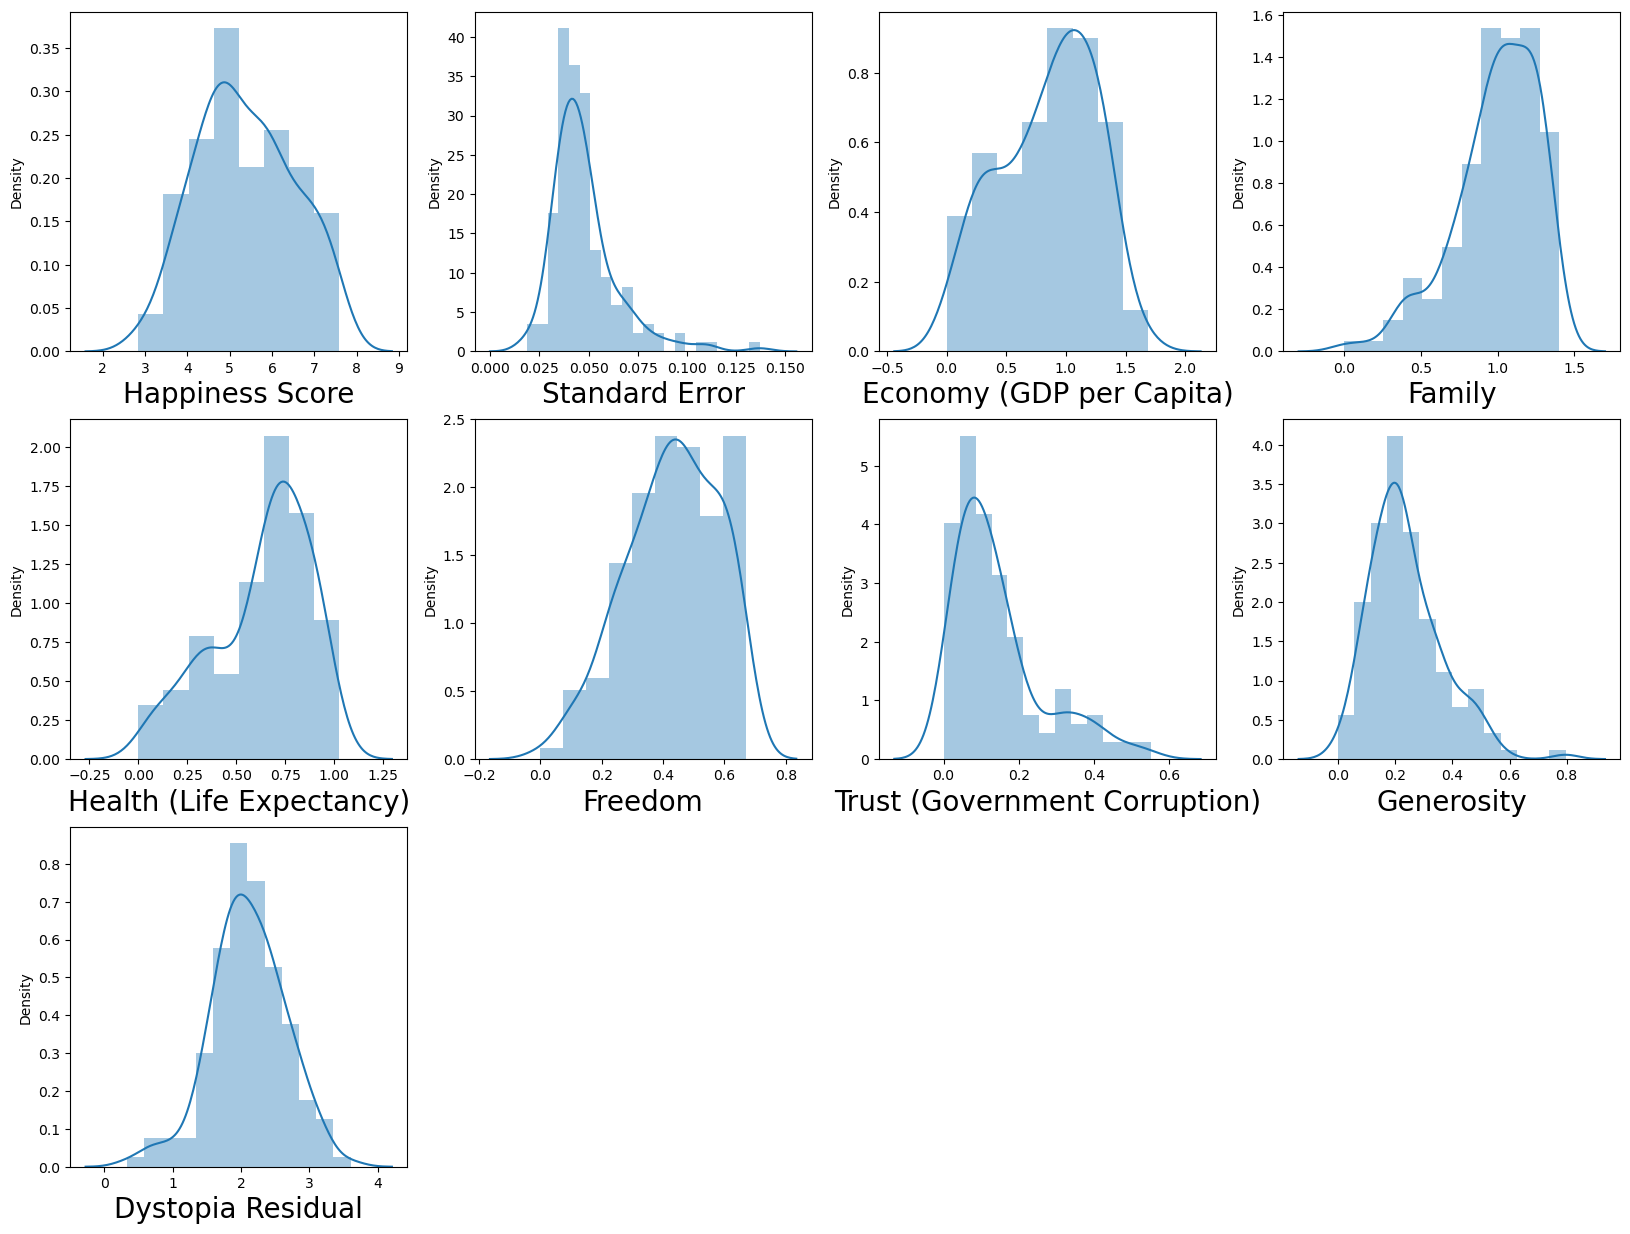

In [27]:
#Lets check how data is distributed
plt.figure(figsize=(20,15))
plotnumber =1
for column in df:
    if plotnumber <=10:
        ax=plt.subplot(3,4,plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.show()

In [28]:
# Some outliers are present in our data

In [31]:
# From this distribution plot we can find some outliers in our data
#Firstly some missing values are present in 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy), 'Freedom' and 'Dystopia Residual', this features can't be zero, we need to solve it

### 3. Data Preprocessing

In [34]:
# Handling Missing values
#replacing zero values with the mean of the column
#i am going to use low risk method its mean method
#treating zeros

In [36]:
data['Family']=data['Family'].replace(0,data['Family'].mean())
data['Dystopia Residual']=df['Dystopia Residual'].replace(0,data['Dystopia Residual'].mean())
data['Economy (GDP per Capita)']=data['Economy (GDP per Capita)'].replace(0,data['Economy (GDP per Capita)'].mean())
data['Health (Life Expectancy)']=data['Health (Life Expectancy)'].replace(0,data['Health (Life Expectancy)'].mean())
data['Freedom']=data['Freedom'].replace(0,data['Freedom'].mean())
data.describe()

,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,5.375734,0.047885,0.851493,0.997318,0.634248,0.431328,0.143422,0.237296,2.098977
std,1.145010,0.017146,0.397388,0.260556,0.241870,0.146734,0.120034,0.126685,0.553550
min,2.839000,0.018480,0.015300,0.139950,0.047760,0.076990,0.000000,0.000000,0.328580
25%,4.526000,0.037268,0.557532,0.861422,0.447215,0.329603,0.061675,0.150553,1.759410
50%,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [39]:
#Describe category name
print(data['Country'].unique())
print(data['Region'].unique())

['Switzerland' 'Iceland' 'Denmark' 'Norway' 'Canada' 'Finland'
 'Netherlands' 'Sweden' 'New Zealand' 'Australia' 'Israel' 'Costa Rica'
 'Austria' 'Mexico' 'United States' 'Brazil' 'Luxembourg' 'Ireland'
 'Belgium' 'United Arab Emirates' 'United Kingdom' 'Oman' 'Venezuela'
 'Singapore' 'Panama' 'Germany' 'Chile' 'Qatar' 'France' 'Argentina'
 'Czech Republic' 'Uruguay' 'Colombia' 'Thailand' 'Saudi Arabia' 'Spain'
 'Malta' 'Taiwan' 'Kuwait' 'Suriname' 'Trinidad and Tobago' 'El Salvador'
 'Guatemala' 'Uzbekistan' 'Slovakia' 'Japan' 'South Korea' 'Ecuador'
 'Bahrain' 'Italy' 'Bolivia' 'Moldova' 'Paraguay' 'Kazakhstan' 'Slovenia'
 'Lithuania' 'Nicaragua' 'Peru' 'Belarus' 'Poland' 'Malaysia' 'Croatia'
 'Libya' 'Russia' 'Jamaica' 'North Cyprus' 'Cyprus' 'Algeria' 'Kosovo'
 'Turkmenistan' 'Mauritius' 'Hong Kong' 'Estonia' 'Indonesia' 'Vietnam'
 'Turkey' 'Kyrgyzstan' 'Nigeria' 'Bhutan' 'Azerbaijan' 'Pakistan' 'Jordan'
 'Montenegro' 'China' 'Zambia' 'Romania' 'Serbia' 'Portugal' 'Latvia'
 'Philip

In [41]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Country'] = le.fit_transform(data['Country'])
data['Region'] = le.fit_transform(data['Region'])

In [42]:
data.head()

,Country,Region,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,135,9,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,58,9,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,37,9,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,105,9,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,24,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


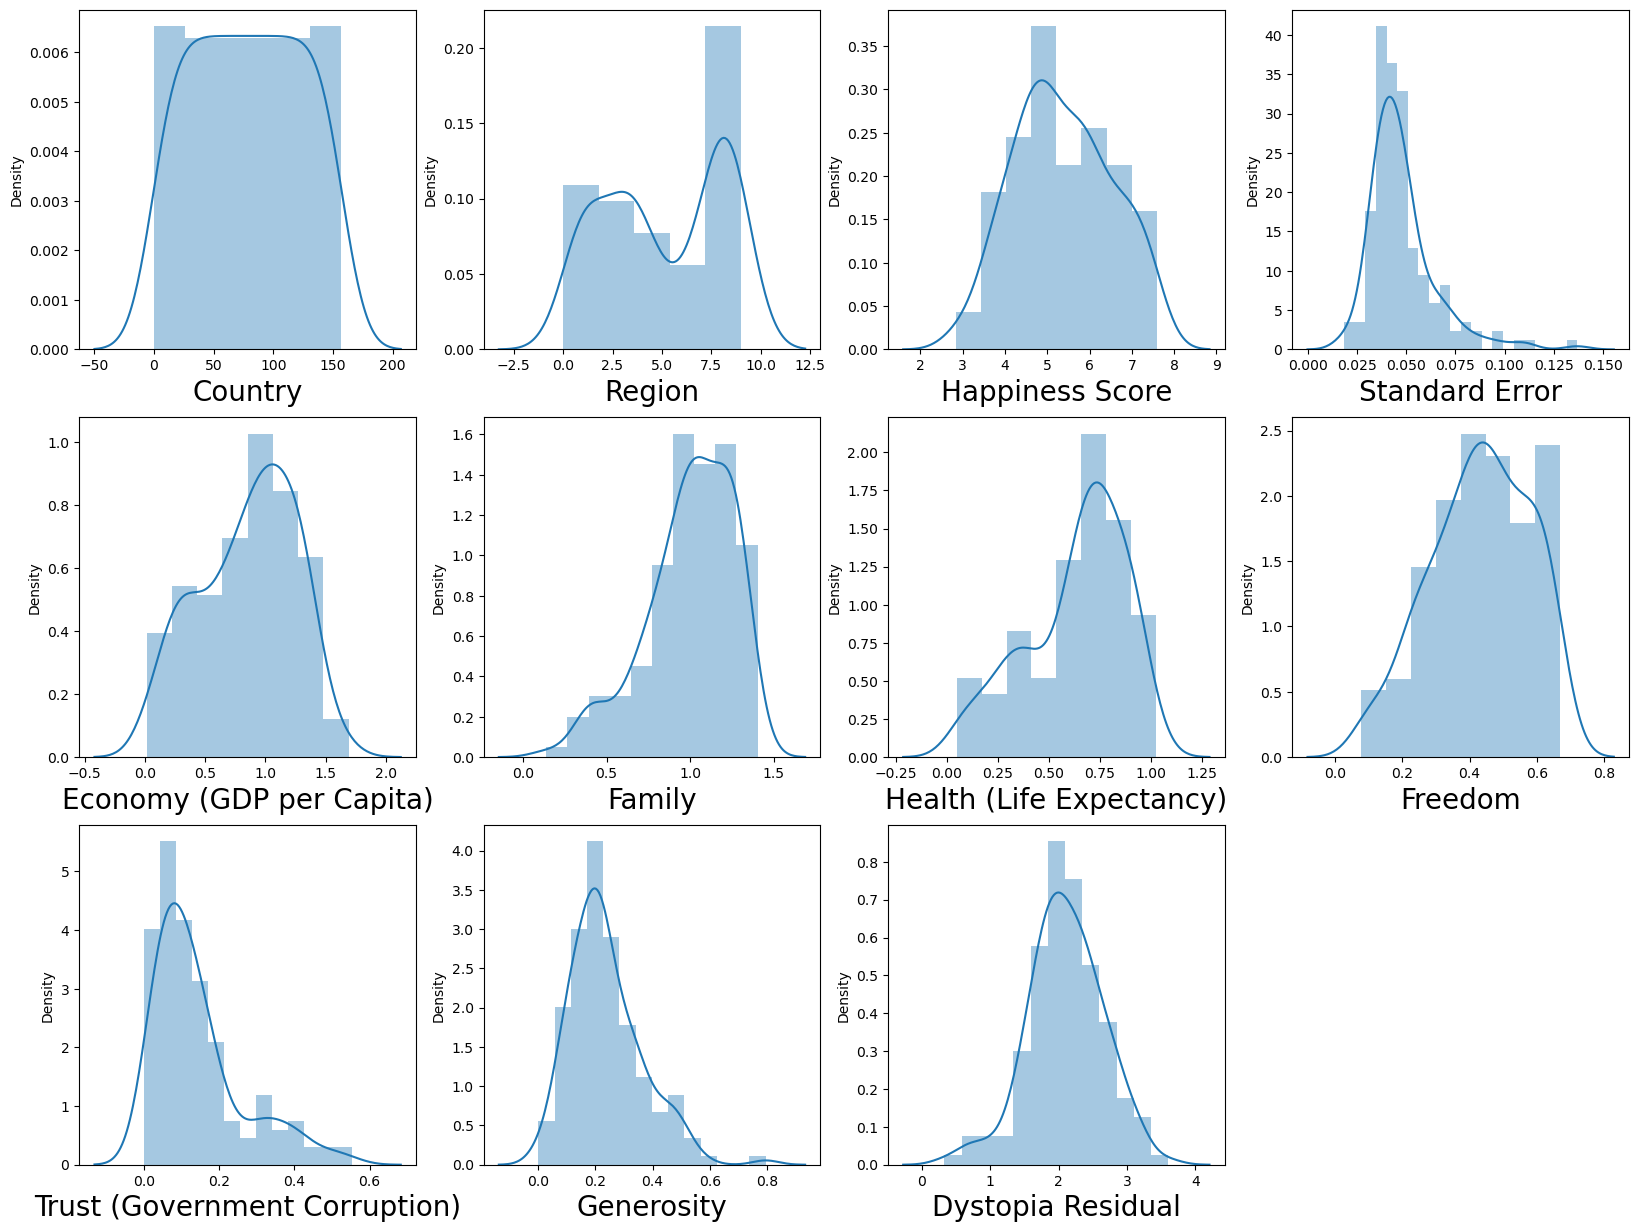

In [45]:
#Lets check how data is distributed
plt.figure(figsize=(20,15))
plotnumber =1
for column in data:
    if plotnumber <=12:
        ax=plt.subplot(3,4,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.show()

In [46]:
# Handing Outliers: In order to handing outliers we need to plot 'box plot'

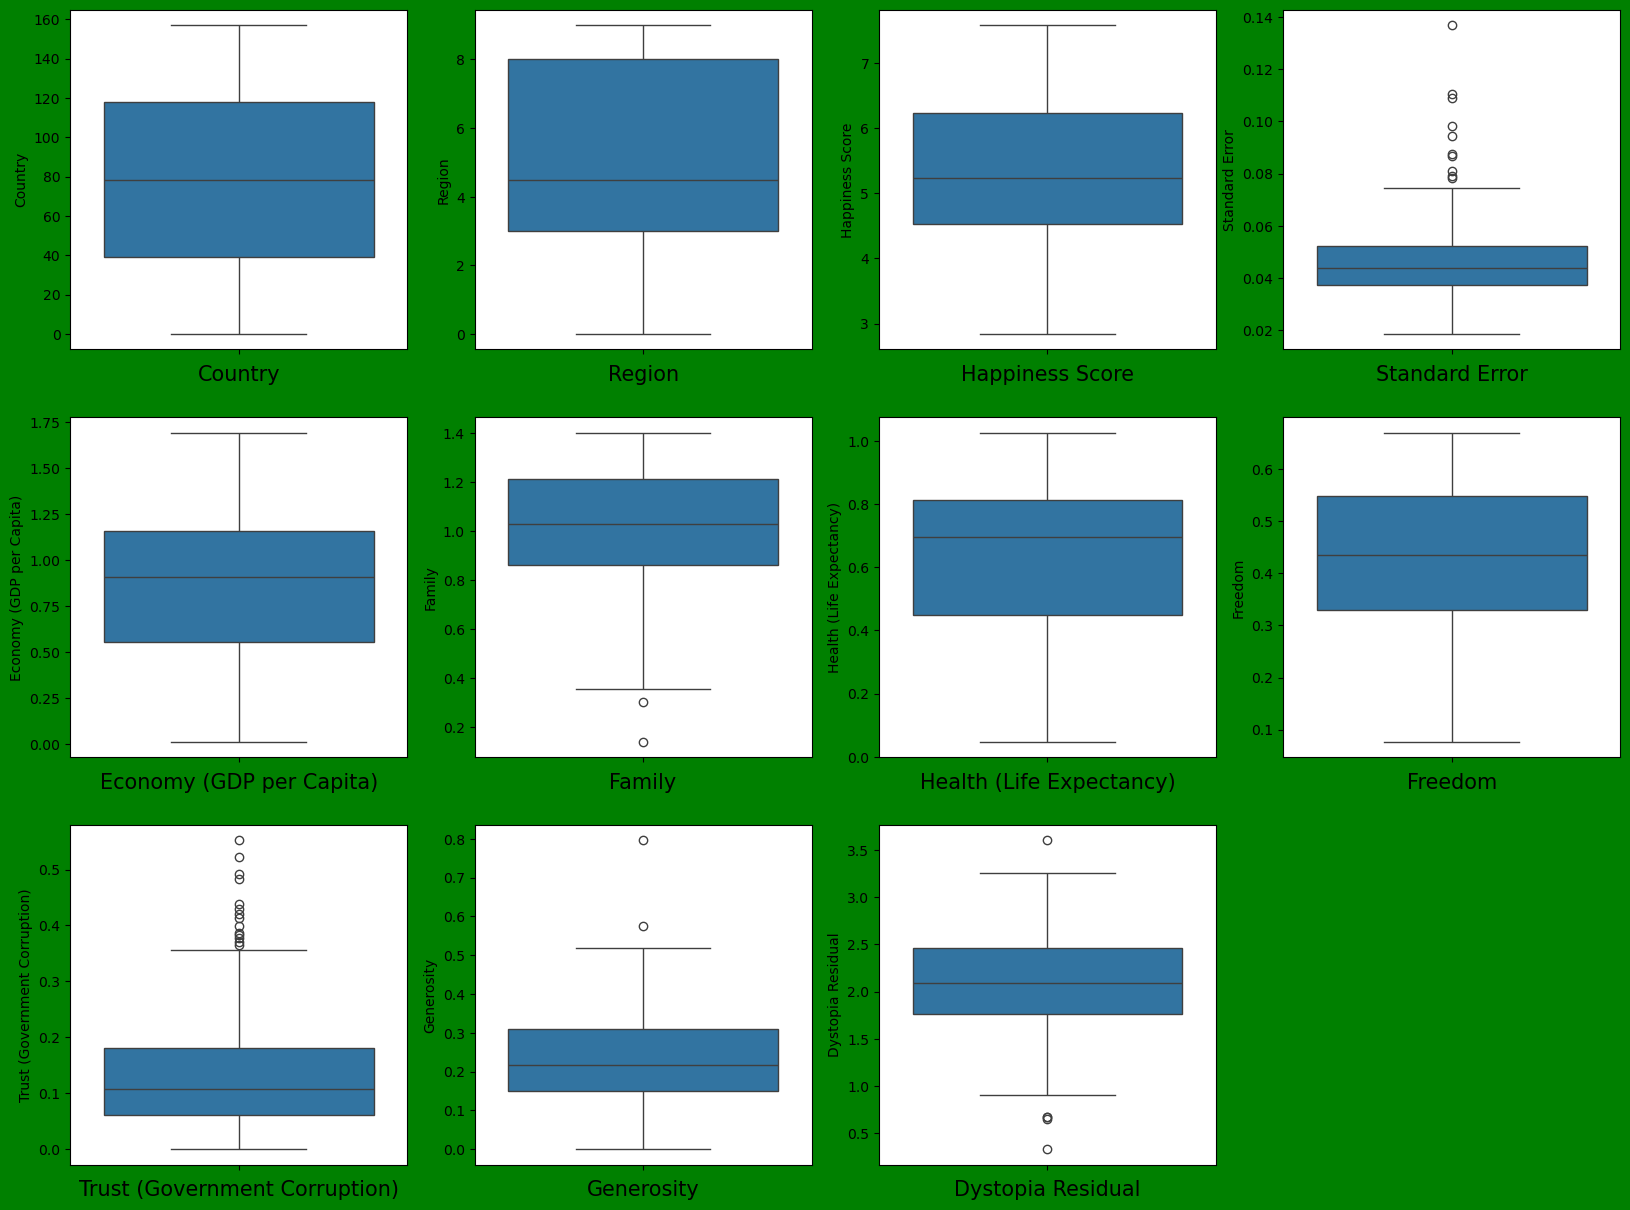

In [49]:
#Visualize the outliers using boxplot
plt.figure(figsize=(20,15),facecolor='green')
plotnumber=1
for column in data:
    if plotnumber <=12:
        plt.subplot(3,4,plotnumber)
        ax=sns.boxplot(data=data[column])
        plt.xlabel(column,fontsize=15)
    plotnumber +=1
plt.show()

In [50]:
#From boxplot we find that we have outliers in 'Standard Error', 'Family', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual   '
#Lets fix this with the using of z score

In [53]:
from scipy.stats import zscore

In [55]:
z_score=zscore(data[['Standard Error', 'Family', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']])
score=np.abs(z_score)
filter=(score <3).all(axis=1)
data=data[filter]
data.shape

(150, 11)

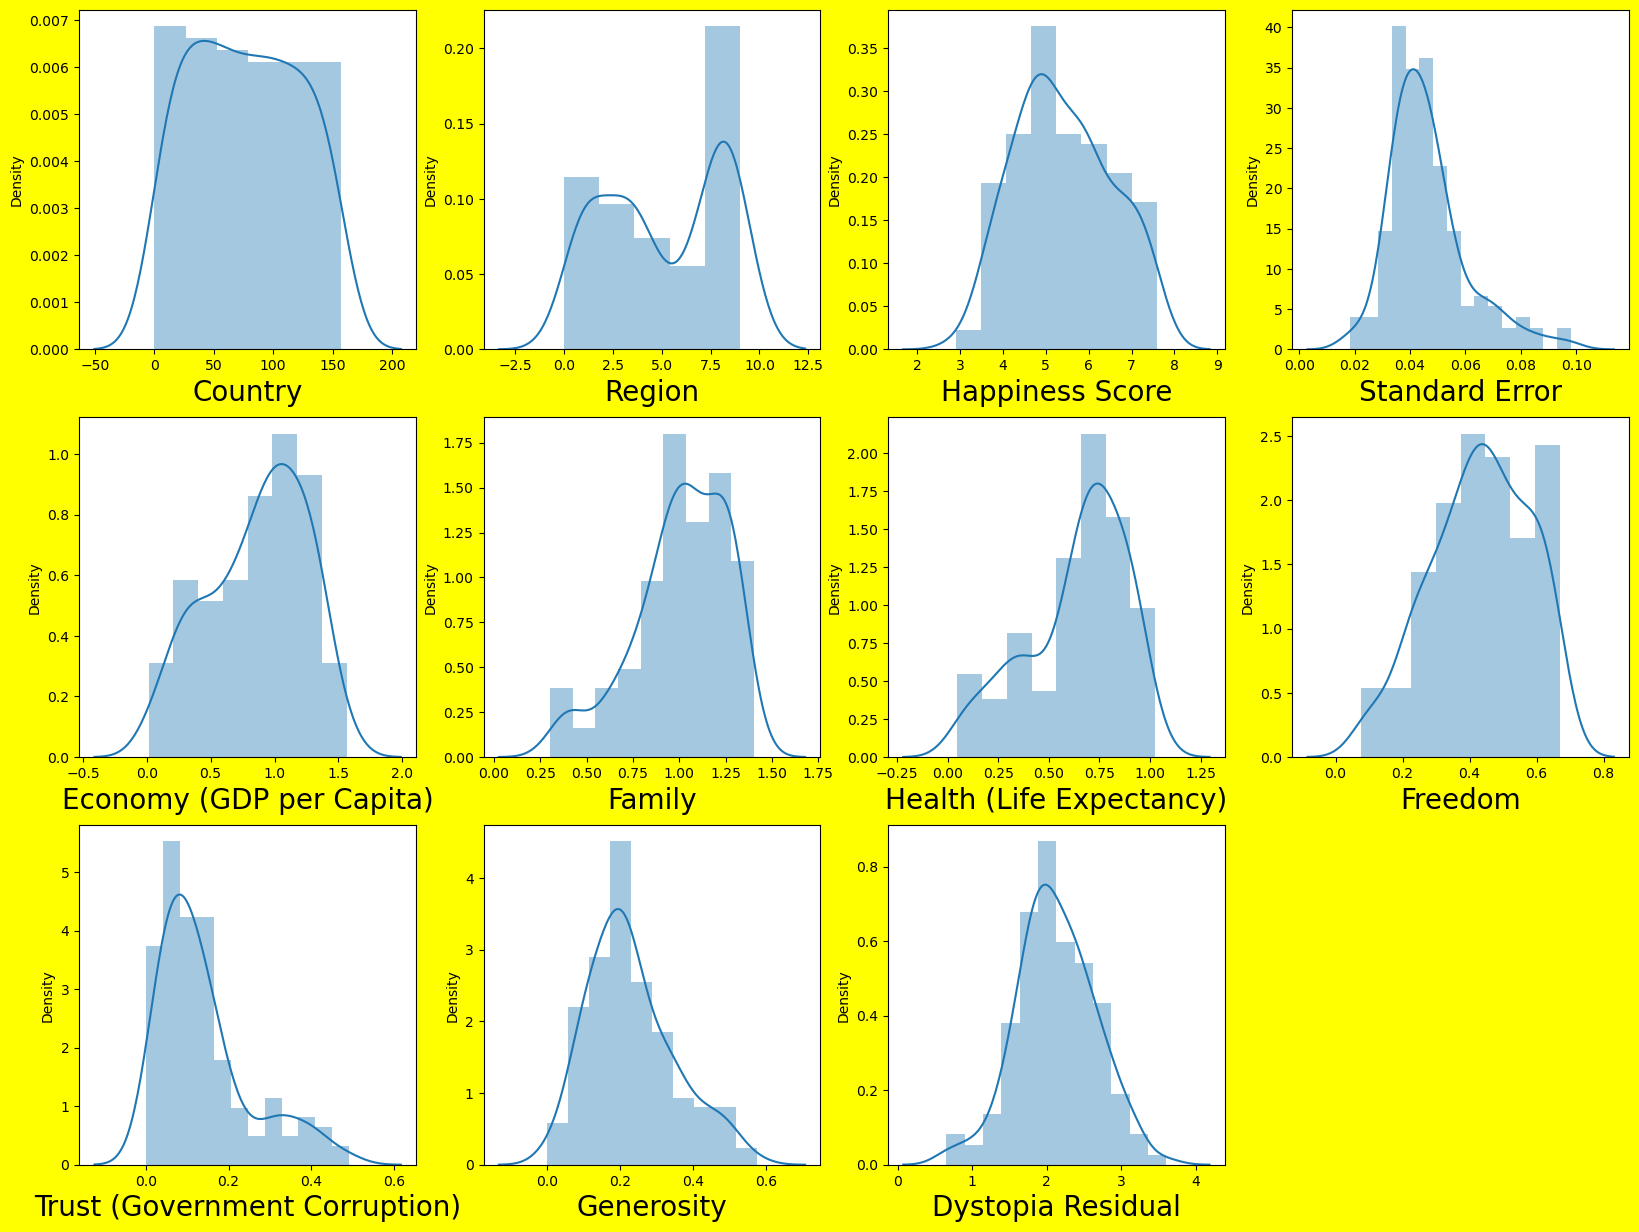

In [57]:
#So, we can plot distribution once again
plt.figure(figsize=(20,15), facecolor='yellow')
plotnumber =1
for column in data:
    if plotnumber <=12:
        ax=plt.subplot(3,4,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
    plotnumber +=1
plt.show()

In [58]:
#Now our data is normaly distributed, we can proceed with feature selection.

#### Feature Selection

In [60]:
#Lets check in VIF .Variance Inflation Factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [61]:
x=data.drop(columns=['Happiness Score'])
y=data['Happiness Score']

In [66]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[ 1.27462525,  1.29071162, -0.87351634, ...,  2.48179921,
         0.54774599,  0.7484519 ],
       [-0.40941978,  1.29071162,  0.17850856, ...,  0.01267166,
         1.7192371 ,  1.10051263],
       [-0.86870479,  1.29071162, -0.93279541, ...,  3.04769454,
         0.92231751,  0.70013246],
       ...,
       [-1.67792123,  0.62880822, -1.10706158, ..., -0.37996868,
         1.12140047, -0.32944923],
       [-1.39360194,  0.95975992, -0.69853596, ..., -0.53157789,
        -0.41097574, -0.93738944],
       [-1.21863622,  0.95975992,  2.8739206 , ..., -0.34954039,
        -0.28779788, -0.55651629]])

In [68]:
vif=pd.DataFrame()
vif['vif']=[variance_inflation_factor(x_scaled,i)for i in range(x_scaled.shape[1])]
vif['features']=x.columns
vif

,vif,features
0,1.067651,Country
1,1.396882,Region
2,1.166608,Standard Error
3,3.916692,Economy (GDP per Capita)
4,2.049062,Family
5,3.498191,Health (Life Expectancy)
6,1.907662,Freedom
7,1.518299,Trust (Government Corruption)
8,1.456496,Generosity
9,1.032535,Dystopia Residual


In [70]:
#We dont have any multicollinearity problem. So we can go for model building

### 4. Model Building
#### Using Regression

In [73]:
# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [106]:
# Split into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [108]:
# Standardize data for models sensitive to scale (e.g., SVR, KNN)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [110]:
# Define models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

In [112]:
# Train and evaluate each model
print("Model Performance of Test data:\n")
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_train_pred = model.predict(x_train_scaled)
    
    #Calculate methrics 
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)
    n = len(y_train)
    p = x.shape[1]
    adj_r2_train = (1-(1-r2_train)*(n-1)/(n-p-1))

    
    #Print all metrics
    print(f"{name}")
    print(f"  MAE: {mae_train:.3f}")
    print(f"  MSE: {mse_train:.3f}")
    print(f"  RMSE: {rmse_train:.3f}")
    print(f"  R_square Score: {r2_train:.3f}")
    print(f"  Adjusted R_square Score: {adj_r2_train:.3f}\n")

Model Performance of Test data:

Linear Regression
  MAE: 0.048
  MSE: 0.011
  RMSE: 0.106
  R_square Score: 0.991
  Adjusted R_square Score: 0.990

Decision Tree
  MAE: 0.000
  MSE: 0.000
  RMSE: 0.000
  R_square Score: 1.000
  Adjusted R_square Score: 1.000

Random Forest
  MAE: 0.105
  MSE: 0.019
  RMSE: 0.140
  R_square Score: 0.984
  Adjusted R_square Score: 0.983



In [114]:
# Test and evaluate each model
print("Model Performance of Test data:\n")

for name, model in models.items():
    model.fit(x_test_scaled, y_test)
    y_test_pred = model.predict(x_test_scaled)
    
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)
    n = len(x_test)
    p = x.shape[1]
    adj_r2_test = (1-(1-r2_test)*(n-1)/(n-p-1))

    
    print(f"{name}")
    print(f"  MAE: {mae_test:.3f}")
    print(f"  MSE: {mse_test:.3f}")
    print(f"  RMSE: {rmse_test:.3f}")
    print(f"  R_square Score: {r2_test:.3f}")
    print(f"  Adjusted R_square Score: {adj_r2_test:.3f}\n")

Model Performance of Test data:

Linear Regression
  MAE: 0.076
  MSE: 0.011
  RMSE: 0.105
  R_square Score: 0.991
  Adjusted R_square Score: 0.986

Decision Tree
  MAE: 0.000
  MSE: 0.000
  RMSE: 0.000
  R_square Score: 1.000
  Adjusted R_square Score: 1.000

Random Forest
  MAE: 0.159
  MSE: 0.037
  RMSE: 0.191
  R_square Score: 0.970
  Adjusted R_square Score: 0.954



### 5. Cross Validation

#### Analysing our r2 score and adjusted r2 score, Our model is not overfitted. So it was  not necessry to check for cross valiadation 

### 6. Hyperparameter Tyning Using RandomizedSearchCV

#### Our model was not necessry to check for cross valiadation. So, no need to do hyperparameter tuning

### 7. Model Save 

In [135]:
import pickle

#### Predicting the happiness score

In [159]:
# LINEAR REGRESSION
LR = LinearRegression()

In [161]:
LR.fit(x_train_scaled, y_train)

LinearRegression()

In [163]:
x.head()

,Country,Region,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,135,9,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,58,9,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,37,9,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,105,9,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,24,5,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [165]:
y.head()

0    7.587
1    7.561
2    7.527
3    7.522
4    7.427
Name: Happiness Score, dtype: float64

In [167]:
# predict the happiness score
#Since we already fit the scaler . you can tranform the data .
print("Happiness Score : ",LR.predict(scaler.transform([[135, 9, 0.03411, 1.39651, 1.34951, 0.94143, 0.66557, 0.41978, 0.29678, 2.51738]])))

Happiness Score :  [7.59256885]


In [169]:
#Saving and loading the model to the local file system 
pickle.dump(LR,open('Happiness Score','wb'))
lr_model=pickle.load(open('Happiness Score','rb'))
lr_model.predict(scaler.transform([[135, 9, 0.03411, 1.39651, 1.34951, 0.94143, 0.66557, 0.41978, 0.29678, 2.51738]]))

array([7.59256885])

In [171]:
# DecisionTreeRegressor
DT=DecisionTreeRegressor()
DT.fit(x_train_scaled, y_train)

DecisionTreeRegressor()

In [173]:
#Saving and loading the model to the local file system 
pickle.dump(DT,open('Happiness Score','wb'))
dt_model=pickle.load(open('Happiness Score','rb'))
dt_model.predict(scaler.transform([[135, 9, 0.03411, 1.39651, 1.34951, 0.94143, 0.66557, 0.41978, 0.29678, 2.51738]]))

array([7.587])

In [175]:
# RandomForestRegressor
RF = RandomForestRegressor(n_estimators=100, random_state=42)
RF.fit(x_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [177]:
#Saving and loading the model to the local file system 
pickle.dump(RF,open('Happiness Score','wb'))
rf_model=pickle.load(open('Happiness Score','rb'))
rf_model.predict(scaler.transform([[135, 9, 0.03411, 1.39651, 1.34951, 0.94143, 0.66557, 0.41978, 0.29678, 2.51738]]))

array([7.5195])

### The three models are predicted accurately